# Homework 3: Models for Classification

## Air Quality Classification (NO2 Levels)

#### **Objetivo:** Classificar o nível de poluição de NO₂ em três categorias (Baixo, Médio, Alto) utilizando modelos lineares e não-lineares implementados do zero.

## 1. Configurações Iniciais

#### **Objetivo:** Preparar o ambiente, importar bibliotecas e garantir reprodutibilidade.

#### **Escopo:** Instalação de dependências, configuração visual e definição da `SEED`.

In [30]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "axes.titlesize": 20,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15,
})


SEED = 42
np.random.seed(SEED)

DATA_PATH = "../database/air_quality_uci.csv"
PATH_FIG = "./doc/figures"
os.makedirs(PATH_FIG, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(PATH_FIG, f"{name}.pdf"), bbox_inches="tight")



## 2. Análise Exploratória

### 2.1 Loading e Limpeza Inicial

- Fonte: `air_quality_uci.csv` (UCI), separador `;`, vírgula como decimal.
- Limpeza: remove colunas vazias e descarta linhas com `NaN` para evitar imputações ad hoc.

In [31]:
air_quality = pd.read_csv(
    DATA_PATH,
    sep=";",
    decimal=",",
    na_values=-200
)

air_quality = air_quality.iloc[:, :-2]

In [32]:
import pandas as pd
import numpy as np

df_real = air_quality.filter(regex=r"\(GT\)$")

stats_real = pd.DataFrame({
    "count": df_real.count(),
    "missing": df_real.isna().sum(),
    "missing_pct": df_real.isna().mean() * 100,
    "min": df_real.min(),
    "mean": df_real.mean(),
    "max": df_real.max()
}).round(2)

display(stats_real.sort_values(by="missing_pct", ascending=False))


,count,missing,missing_pct,min,mean,max
NMHC(GT),914,8557,90.35,7.0,218.81,1189.0
CO(GT),7674,1797,18.97,0.1,2.15,11.9
NO2(GT),7715,1756,18.54,2.0,113.09,340.0
NOx(GT),7718,1753,18.51,2.0,246.90,1479.0
C6H6(GT),8991,480,5.07,0.1,10.08,63.7


In [33]:
df_sensors = air_quality.filter(regex=r"^PT08")

stats_sensors = pd.DataFrame({
    "count": df_sensors.count(),
    "missing": df_sensors.isna().sum(),
    "missing_pct": df_sensors.isna().mean() * 100,
    "min": df_sensors.min(),
    "mean": df_sensors.mean(),
    "max": df_sensors.max()
}).round(2)

display(stats_sensors.sort_values(by="missing_pct", ascending=False))


,count,missing,missing_pct,min,mean,max
PT08.S1(CO),8991,480,5.07,647.0,1099.83,2040.0
PT08.S2(NMHC),8991,480,5.07,383.0,939.15,2214.0
PT08.S3(NOx),8991,480,5.07,322.0,835.49,2683.0
PT08.S4(NO2),8991,480,5.07,551.0,1456.26,2775.0
PT08.S5(O3),8991,480,5.07,221.0,1022.91,2523.0


In [34]:
import pandas as pd
import numpy as np

df_num = air_quality.select_dtypes(include=[np.number])

labels = pd.Series("other", index=df_num.columns)
labels[df_num.filter(regex=r"\(GT\)$").columns] = "real"
labels[df_num.filter(regex=r"^PT08").columns] = "sensor"
labels[["T", "RH", "AH"]] = "env"

stats_table = (
    pd.DataFrame({
        "label": labels,
        "count": df_num.count(),
        "missing": df_num.isna().sum(),
        "missing_pct": df_num.isna().mean() * 100,
        "min": df_num.min(),
        "mean": df_num.mean(),
        "max": df_num.max()
    })
    .round(2)
    .sort_values(by=["label", "missing_pct"], ascending=[True, False])
)

display(stats_table)


,label,count,missing,missing_pct,min,mean,max
T,env,8991,480,5.07,-1.90,18.32,44.60
RH,env,8991,480,5.07,9.20,49.23,88.70
AH,env,8991,480,5.07,0.18,1.03,2.23
NMHC(GT),real,914,8557,90.35,7.00,218.81,1189.00
CO(GT),real,7674,1797,18.97,0.10,2.15,11.90
NO2(GT),real,7715,1756,18.54,2.00,113.09,340.00
NOx(GT),real,7718,1753,18.51,2.00,246.90,1479.00
C6H6(GT),real,8991,480,5.07,0.10,10.08,63.70
PT08.S1(CO),sensor,8991,480,5.07,647.00,1099.83,2040.00
PT08.S2(NMHC),sensor,8991,480,5.07,383.00,939.15,2214.00


### 2.2 Análise de Valores Faltantes e Outliers

- Análise de missing values: contagem e porcentagem por coluna.
- Remoção de coluna `NMHC(GT)` com muitos valores faltantes.

In [35]:
print("\nMissing Values and Percentage (%):")
missing = air_quality.isnull().sum()
percent = (missing / len(air_quality) * 100).round(2)
missing_df = pd.DataFrame({"Missing Values": missing, "Percentage (%)": percent})
display(missing_df.sort_values("Missing Values", ascending=False))
print(f"\nTotal missing values: {missing.sum()}")


Missing Values and Percentage (%):


,Missing Values,Percentage (%)
NMHC(GT),8557,90.35
CO(GT),1797,18.97
NO2(GT),1756,18.54
NOx(GT),1753,18.51
PT08.S2(NMHC),480,5.07
C6H6(GT),480,5.07
PT08.S1(CO),480,5.07
PT08.S5(O3),480,5.07
T,480,5.07
PT08.S3(NOx),480,5.07



Total missing values: 18411


In [36]:
air_quality = air_quality.drop(columns=["NMHC(GT)"])

### 2.3 Estatísticas Descritivas e Visualizações

- Tabela de estatísticas descritivas das variáveis numéricas.
- Série temporal do NO₂ para avaliar estabilidade e tendências.
- Boxplots normalizados para detectar outliers e comparar escalas entre variáveis.

=== Tabela de Estatística Descritiva ===


,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.15,1.45,0.10,1.10,1.8,2.90,11.90
PT08.S1(CO),8991.0,1099.83,217.08,647.00,937.00,1063.0,1231.00,2040.00
C6H6(GT),8991.0,10.08,7.45,0.10,4.40,8.2,14.00,63.70
PT08.S2(NMHC),8991.0,939.15,266.83,383.00,734.50,909.0,1116.00,2214.00
NOx(GT),7718.0,246.90,212.98,2.00,98.00,180.0,326.00,1479.00
PT08.S3(NOx),8991.0,835.49,256.82,322.00,658.00,806.0,969.50,2683.00
NO2(GT),7715.0,113.09,48.37,2.00,78.00,109.0,142.00,340.00
PT08.S4(NO2),8991.0,1456.26,346.21,551.00,1227.00,1463.0,1674.00,2775.00
PT08.S5(O3),8991.0,1022.91,398.48,221.00,731.50,963.0,1273.50,2523.00
T,8991.0,18.32,8.83,-1.90,11.80,17.8,24.40,44.60


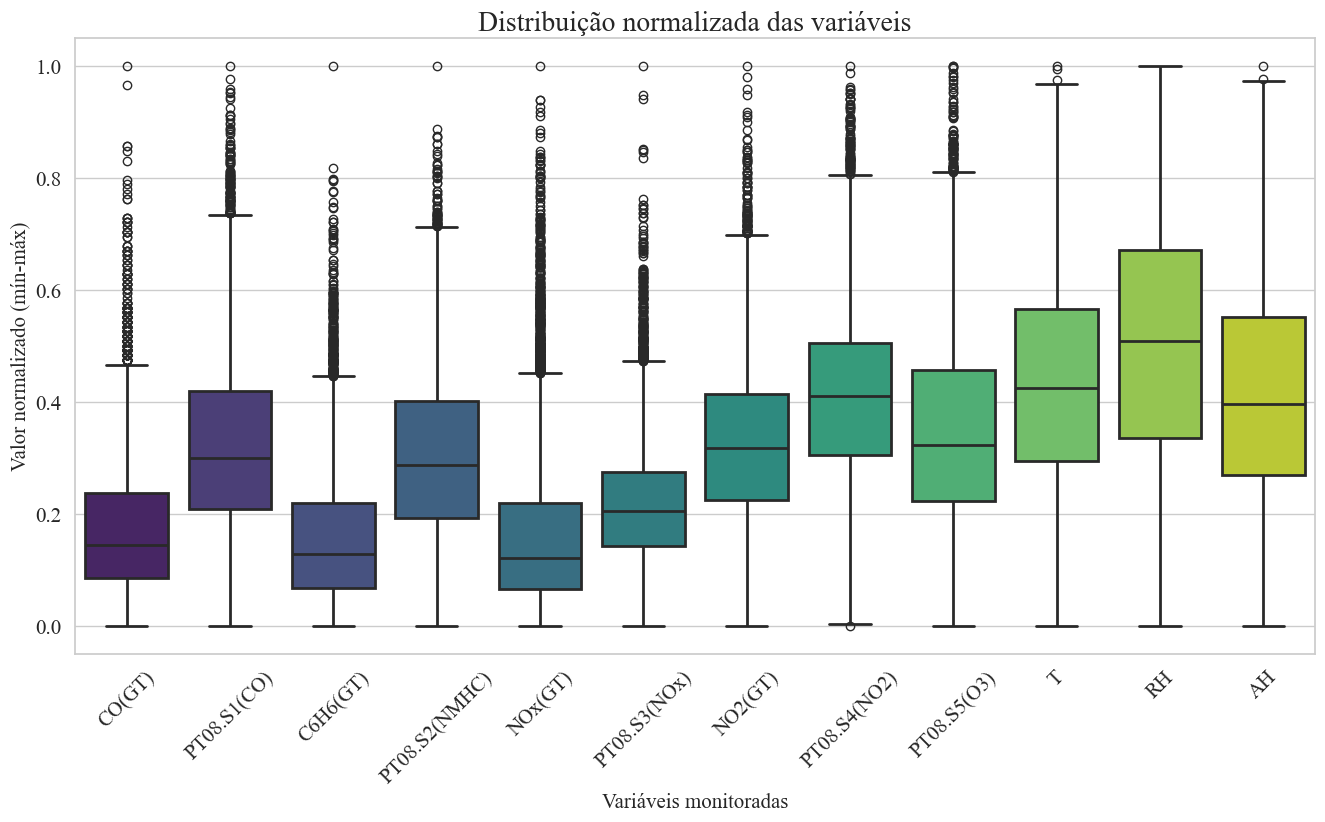

In [37]:
print("=== Tabela de Estatística Descritiva ===")
display(air_quality.describe().T.round(2))


# Boxplots e Análise de Outliers
# Seleciona apenas colunas numéricas
df_numeric = air_quality.select_dtypes(include=[np.number])

# Normalização Min-Max para visualização
df_norm_viz = (df_numeric - df_numeric.min()) / \
    (df_numeric.max() - df_numeric.min())

plt.figure(figsize=(16, 8))
sns.boxplot(data=df_norm_viz, palette="viridis", linewidth=2)
plt.xticks(rotation=45)
plt.title("Distribuição normalizada das variáveis")
plt.xlabel("Variáveis monitoradas")
plt.ylabel("Valor normalizado (mín-máx)")
savefig("eda_boxplots_outliers")
plt.show()

## 3. Preparação dos Dados (Target Engineering)

#### **Objetivo:** Transformar o problema original de regressão em classificação.

#### **Estratégia:** Discretizar a variável contínua `NO2(GT)` em classes balanceadas.

### 3.1 Criação do Índice de Poluição

#### Calcula um índice composto baseado nos poluentes principais para representar o nível geral de poluição.

In [38]:
pollutants = ["CO(GT)", "C6H6(GT)", "NOx(GT)", "NO2(GT)"]
air_quality = air_quality.dropna(subset=pollutants)

X_poll = air_quality[pollutants]

median = X_poll.median()
iqr = X_poll.quantile(0.75) - X_poll.quantile(0.25)

X_norm = (X_poll - median) / iqr

air_quality["PollutionIndex"] = X_norm.mean(axis=1)
air_quality

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,PollutionIndex
0,10/03/2004,18.00.00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,0.167472
1,10/03/2004,19.00.00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,-0.131515
2,10/03/2004,20.00.00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,0.003427
3,10/03/2004,21.00.00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,0.084509
4,10/03/2004,22.00.00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,-0.136403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,0.913451
9353,04/04/2005,11.00.00,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,0.590221
9354,04/04/2005,12.00.00,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,0.535466
9355,04/04/2005,13.00.00,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139,0.281160


In [39]:
air_quality

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,PollutionIndex
0,10/03/2004,18.00.00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,0.167472
1,10/03/2004,19.00.00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,-0.131515
2,10/03/2004,20.00.00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,0.003427
3,10/03/2004,21.00.00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,0.084509
4,10/03/2004,22.00.00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,-0.136403
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9352,04/04/2005,10.00.00,3.1,1314.0,13.5,1101.0,472.0,539.0,190.0,1374.0,1729.0,21.9,29.3,0.7568,0.913451
9353,04/04/2005,11.00.00,2.4,1163.0,11.4,1027.0,353.0,604.0,179.0,1264.0,1269.0,24.3,23.7,0.7119,0.590221
9354,04/04/2005,12.00.00,2.4,1142.0,12.4,1063.0,293.0,603.0,175.0,1241.0,1092.0,26.9,18.3,0.6406,0.535466
9355,04/04/2005,13.00.00,2.1,1003.0,9.5,961.0,235.0,702.0,156.0,1041.0,770.0,28.3,13.5,0.5139,0.281160


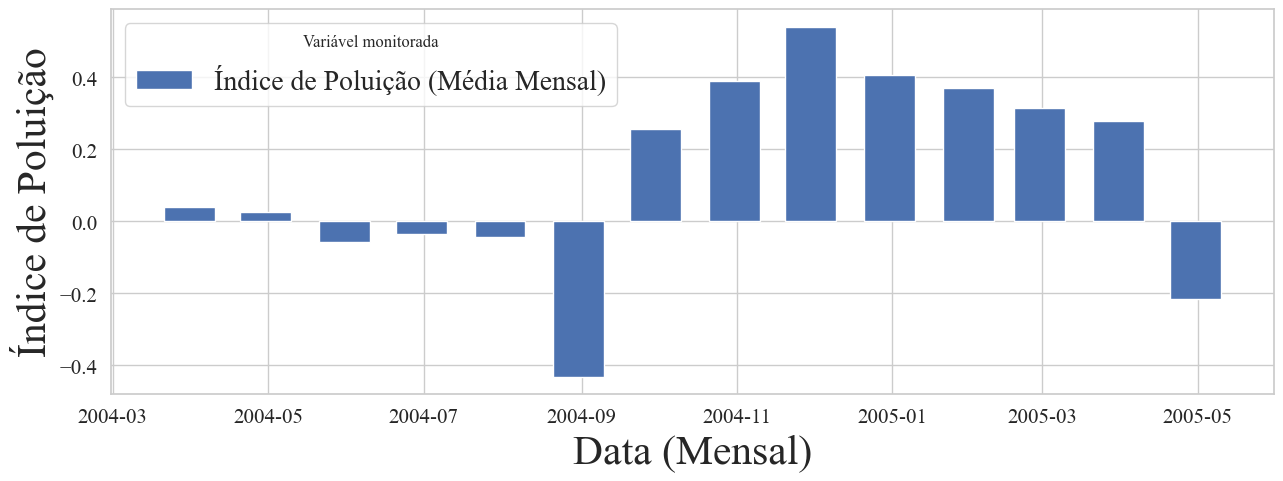

In [40]:
# criar coluna datetime com base nas colunas Date e Time
air_quality['datetime'] = pd.to_datetime(air_quality['Date'] + ' ' + air_quality['Time'], format='%d/%m/%Y %H.%M.%S')
air_quality = air_quality.set_index('datetime')

monthly_pollution = air_quality["PollutionIndex"].resample("M").mean()

plt.figure(figsize=(15, 5))
plt.bar(monthly_pollution.index, monthly_pollution.values, label="Índice de Poluição (Média Mensal)", width=20)
# plt.title("Série temporal mensal do índice de poluição multivariado")
plt.xlabel("Data (Mensal)", fontsize=30)
plt.ylabel("Índice de Poluição", fontsize=30)
plt.legend(title="Variável monitorada", fontsize=20)
savefig("eda_temporal_behavior_monthly")
plt.show()


### 3.2 Discretização do Alvo Categórico

#### Utilizamos quantis para dividir o índice de poluição em classes balanceadas (Very Low, Low, Moderate, High, Critical).

### 3.3 Análise Exploratória Adicional (Distribuição por Turno e Dia da Semana)

- Criação de features temporais: turno do dia e dia da semana.
- Distribuição percentual das classes de poluição por turno.
- Distribuição percentual das classes de poluição por dia da semana.
- Pairplot para visualizar correlações entre poluentes e classes de poluição.

,min,max,count,percentage
PollutionClass,,,,
Muito baixo,-1.036621,-0.635154,695,10.01
Baixo,-0.635123,-0.294342,1388,20.00
Moderado,-0.294255,0.427735,2776,39.99
Alto,0.428389,1.167659,1388,20.00
Crítico,1.168224,4.217857,694,10.00


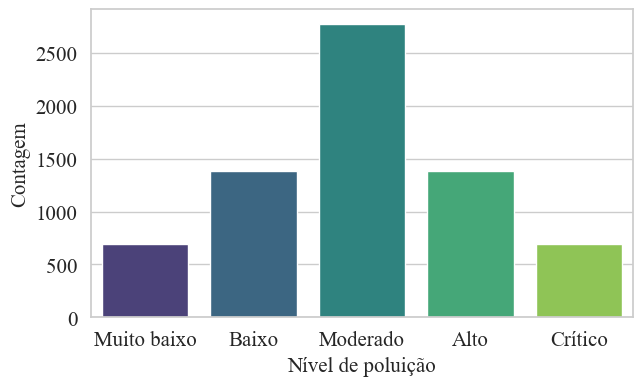

In [41]:
quantiles = air_quality["PollutionIndex"].quantile(
    [0.10, 0.30, 0.70, 0.90]
).values

bins = [-np.inf, quantiles[0], quantiles[1], quantiles[2], quantiles[3], np.inf]
labels = ["Muito baixo", "Baixo", "Moderado", "Alto", "Crítico"]

air_quality["PollutionClass"] = pd.cut(
    air_quality["PollutionIndex"],
    bins=bins,
    labels=labels,
    ordered=True
)
summary = (
    air_quality
    .groupby("PollutionClass")["PollutionIndex"]
    .agg(["min", "max", "count"])
)

summary["percentage"] = 100 * summary["count"] / summary["count"].sum()
display(summary.round({"percentage": 2}))
plt.figure(figsize=(7, 4))
sns.countplot(x=air_quality["PollutionClass"], palette="viridis")
plt.xlabel("Nível de poluição")
plt.ylabel("Contagem")
savefig("target_distribution")
plt.show()



In [42]:
air_quality = air_quality.dropna(subset=["Time", "Date"])

air_quality["Hour"] = air_quality["Time"].str.slice(0, 2).astype(int)

def define_turno(hour):
    if 0 <= hour <= 5:
        return "Madrugada"
    elif 6 <= hour <= 11:
        return "Manhã"
    elif 12 <= hour <= 17:
        return "Tarde"
    else:
        return "Noite"

air_quality["Turno"] = air_quality["Hour"].apply(define_turno)
turno_summary = (
    air_quality
    .groupby(["Turno", "PollutionClass"])
    .size()
    .reset_index(name="count")
)

turno_summary["percentage"] = (
    turno_summary["count"]
    / turno_summary.groupby("Turno")["count"].transform("sum")
) * 100

turno_summary.pivot(
    index="Turno",
    columns="PollutionClass",
    values="percentage"
).round(2)

PollutionClass,Muito baixo,Baixo,Moderado,Alto,Crítico
Turno,,,,,
Madrugada,31.04,35.09,29.33,3.69,0.85
Manhã,8.36,19.64,36.35,23.93,11.72
Noite,0.92,13.14,43.86,25.91,16.17
Tarde,4.73,15.70,47.91,22.60,9.07


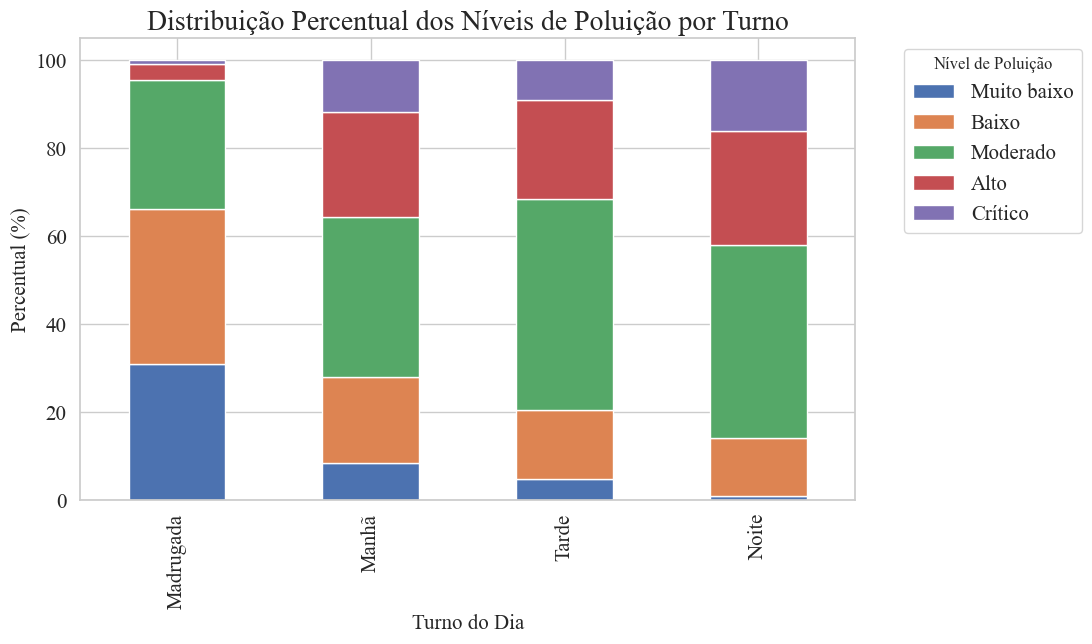

In [43]:
pivot_plot = turno_summary.pivot(
    index="Turno",
    columns="PollutionClass",
    values="percentage"
)

pivot_plot = pivot_plot.loc[["Madrugada", "Manhã", "Tarde", "Noite"]]

pivot_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Distribuição Percentual dos Níveis de Poluição por Turno")
plt.xlabel("Turno do Dia")
plt.ylabel("Percentual (%)")
plt.legend(title="Nível de Poluição", bbox_to_anchor=(1.05, 1), loc="upper left")
savefig("pollution_level_by_turno")
plt.show()



PollutionClass,Muito baixo,Baixo,Moderado,Alto,Crítico
DayOfWeek,,,,,
Monday,11.26,20.87,41.07,18.74,8.06
Tuesday,10.65,15.38,36.56,23.33,14.09
Wednesday,5.93,17.46,39.01,23.38,14.22
Thursday,6.97,16.60,37.50,24.59,14.34
Friday,6.97,12.65,40.84,25.90,13.65
Saturday,7.32,24.13,47.23,15.87,5.45
Sunday,20.73,31.94,36.90,9.13,1.29


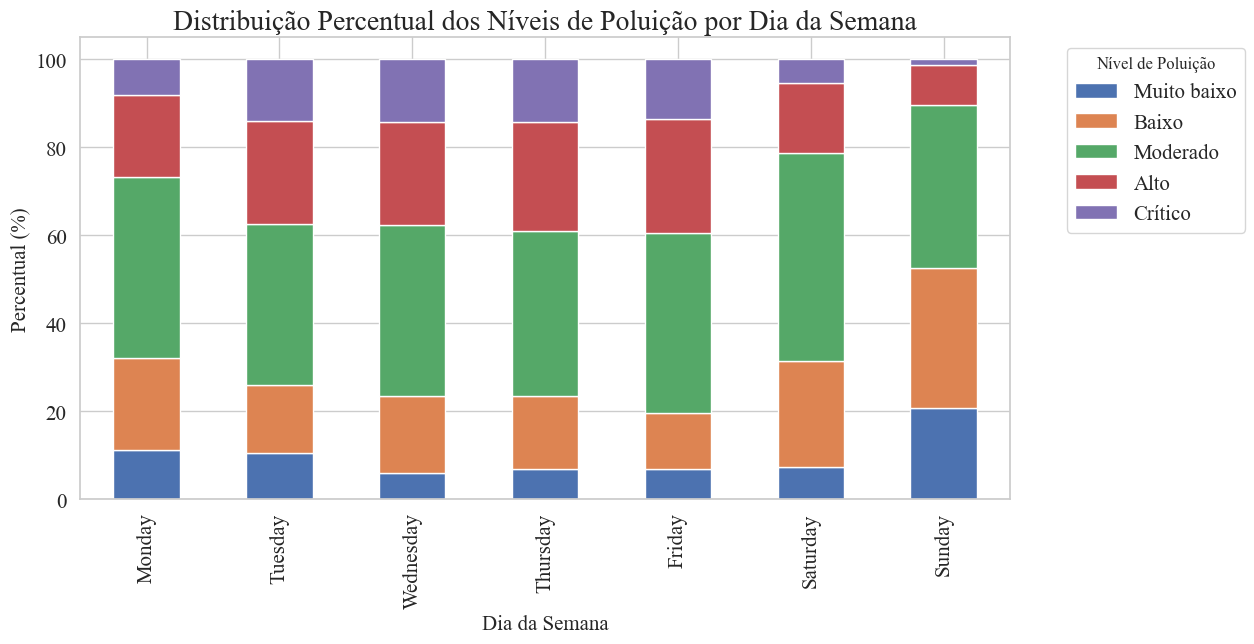

In [44]:

air_quality["Date_dt"] = pd.to_datetime(
    air_quality["Date"],
    format="%d/%m/%Y"
)

air_quality["DayOfWeek"] = air_quality["Date_dt"].dt.day_name()

weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

air_quality["DayOfWeek"] = pd.Categorical(
    air_quality["DayOfWeek"],
    categories=weekday_order,
    ordered=True
)
weekday_summary = (
    air_quality
    .groupby(["DayOfWeek", "PollutionClass"])
    .size()
    .reset_index(name="count")
)

weekday_summary["percentage"] = (
    weekday_summary["count"]
    / weekday_summary.groupby("DayOfWeek")["count"].transform("sum")
) * 100

display(
    weekday_summary
    .pivot(index="DayOfWeek", columns="PollutionClass", values="percentage")
    .round(2)
)

pivot_weekday = weekday_summary.pivot(
    index="DayOfWeek",
    columns="PollutionClass",
    values="percentage"
)

pivot_weekday = pivot_weekday.loc[weekday_order]

pivot_weekday.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Distribuição Percentual dos Níveis de Poluição por Dia da Semana")
plt.xlabel("Dia da Semana")
plt.ylabel("Percentual (%)")
plt.legend(title="Nível de Poluição", bbox_to_anchor=(1.05, 1), loc="upper left")
savefig("pollution_level_by_weekday")
plt.show()


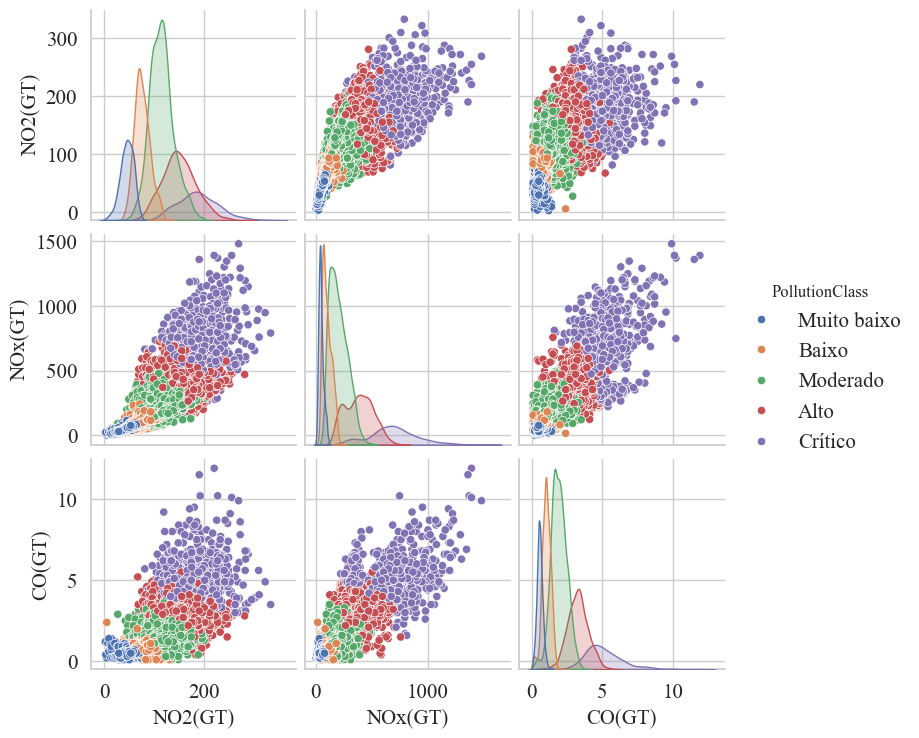

In [45]:
vars_to_plot = ["NO2(GT)", "NOx(GT)", "CO(GT)"]
sns.pairplot(
    air_quality,
    vars=vars_to_plot,
    hue="PollutionClass",
    diag_kind="kde"
)
plt.show()
    

## 4. Definição de Variáveis e Split

#### **Objetivo:** Separar preditores ($X$) e alvo ($y$) e dividir em treino/teste. O alvo categórico precisa ser convertido para números para os modelos matemáticos.

### 4.1 Seleção de Preditores e Encoding do Alvo

#### **X:** Variáveis numéricas (sensores + meteorologia), excluindo o target original, poluentes individuais, e features temporais (Date, Time, etc.).

#### **y:** Mapeamento das classes categóricas ('Very Low', 'Low', 'Moderate', 'High', 'Critical') para inteiros (0, 1, 2, 3, 4) usando LabelEncoder.

### 4.2 Divisão Treino e Teste (Estratificada)

#### Divisão 70/30.

#### **Importante:** Usamos `stratify=y` para garantir que a proporção de classes seja mantida identicamente nos conjuntos de treino e teste.

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X = air_quality.drop(
    columns=[
        "PollutionIndex",
        "PollutionClass",
        "Date",
        "Time",
        "Date_dt",
        "Hour",
        "Turno",
        "DayOfWeek",
        "CO(GT)",
        "C6H6(GT)",
        "NOx(GT)",
        "NO2(GT)"
    ]
)

y = air_quality["PollutionClass"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

perm = np.random.permutation(len(X_train))
X_train = X_train[perm]
y_train = y_train.iloc[perm].reset_index(drop=True)

print(f"Dimensões do Treino: {X_train.shape}")
print(f"Dimensões do Teste:  {X_test.shape}")


Dimensões do Treino: (4858, 8)
Dimensões do Teste:  (2083, 8)


## 5. Pipeline de Pré-processamento

#### **Objetivo:** Preparar os dados para convergência dos algoritmos de gradiente.

#### **Preditores (X):** Log transform (para assimetria) + Z-Score (padronização).

#### **Alvo (y):** One-Hot Encoding necessário para a Rede Neural Manual (vetor de probabilidades).

### 5.1 Implementação do Pipeline

#### A função `process_data_classification` aplica as transformações calculadas no treino e replica no teste para evitar *data leakage*.

#### Processa os preditores (X): log transform para assimetria (se skewness > 0.75) + Z-Score padronização.

#### Gera y one-hot encoded para Rede Neural (MLP), mas o alvo categórico original é mantido para encoding posterior em modelos lineares.

## 6. Modelagem Linear
# Objetivo

- Treinar modelos de classificação linear utilizando os preditores disponíveis no conjunto de treinamento e avaliar seu desempenho no conjunto de teste, analisando a capacidade de generalização e a adequação dos modelos à estrutura dos dados.

# Características do Problema

- Número de preditores: 8 variáveis numéricas (sensores e variáveis meteorológicas), após o pré-processamento

-  Tipo de tarefa: Classificação multiclasse

-  Conjuntos de dados: Treinamento e teste

# 6.1 Regressão Logística Multiclasse

A Regressão Logística Multiclasse foi utilizada como um modelo linear discriminativo, cujo objetivo é estimar diretamente a probabilidade condicional das classes dado o vetor de características. Para lidar com o cenário multiclasse, foi empregado o solver lbfgs, que é adequado para problemas com múltiplas classes e apresenta boa eficiência computacional e estabilidade numérica.

Esse modelo se destaca por sua simplicidade, interpretabilidade e baixo custo computacional, além de exigir menos hipóteses estatísticas sobre a distribuição dos dados. Dessa forma, a Regressão Logística serve como um importante baseline para comparação com modelos mais complexos, permitindo avaliar se ganhos de desempenho justificam o aumento da complexidade.

Acurácia geral: 0.8243
Matriz de confusão:
[[323   0  20  74   0]
 [  0 328   0  64  24]
 [ 41   0 167   0   0]
 [ 41  62   0 730   0]
 [  0  39   0   1 169]]


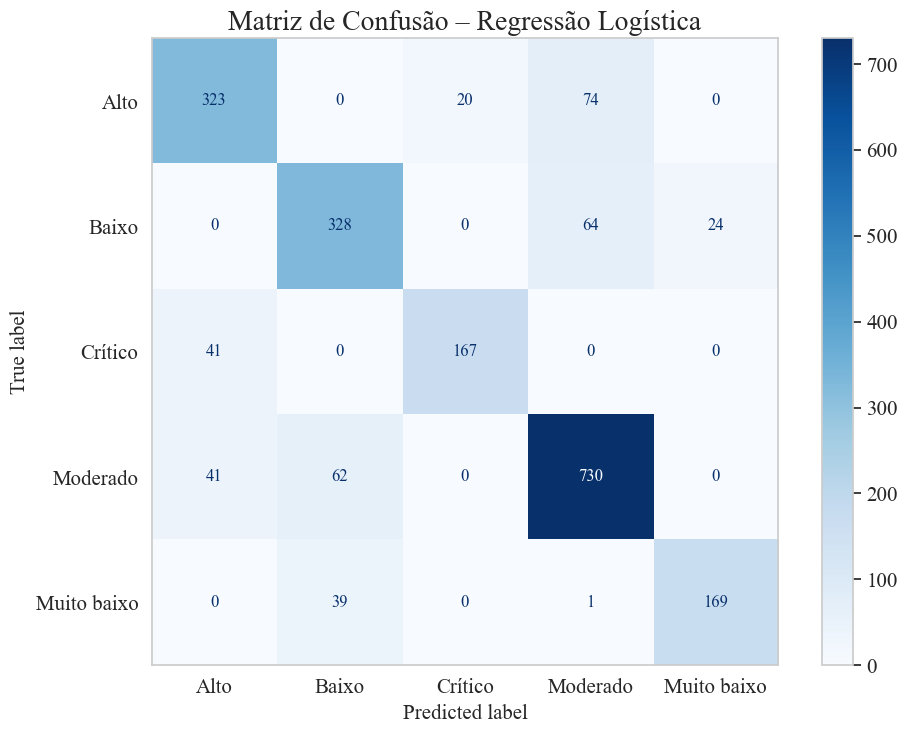

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Codificação do alvo categórico para inteiros
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Definição do modelo de Regressão Logística Multiclasse
logistic_model = LogisticRegression(
    solver="lbfgs",
    max_iter=1000,
    random_state=SEED
)

# Treinamento do modelo
logistic_model.fit(X_train, y_train_enc)

# Previsão no conjunto de teste
y_pred = logistic_model.predict(X_test)


# Avaliação do desempenho
accuracy = accuracy_score(y_test_enc, y_pred)
cm = confusion_matrix(y_test_enc, y_pred)

print(f"Acurácia geral: {accuracy:.4f}")
print("Matriz de confusão:")
print(cm)

fig, ax = plt.subplots(figsize=(10, 7.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap=plt.cm.Blues)

ax.grid(False)

plt.title("Matriz de Confusão – Regressão Logística")
plt.tight_layout()
plt.show()


Apresentou-se como um forte competidor com acurácia de 0.8243. O modelo é eficiente e consistente, especialmente na classe Baixo (326 acertos). Entretanto, demonstra uma tendência conservadora ao classificar 74 casos da classe Alto como Moderado, sugerindo uma sobreposição linear nessas fronteiras de decisão.

## 6.2 Linear Discriminant Analysis (LDA)

A Linear Discriminant Analysis (LDA) foi aplicada como um modelo linear generativo, baseado na suposição de que os dados de cada classe seguem uma distribuição normal multivariada e compartilham a mesma matriz de covariância. A partir dessas hipóteses, o LDA busca encontrar combinações lineares das variáveis que maximizem a separação entre as classes.

Comparada à Regressão Logística, a LDA impõe restrições estatísticas mais fortes, o que pode resultar em melhor desempenho quando tais hipóteses são razoavelmente satisfeitas, especialmente em conjuntos de dados de menor dimensão. Por outro lado, sua sensibilidade à estimativa correta dos parâmetros pode limitar sua eficácia em cenários mais complexos ou com maior variabilidade.

Acurácia geral: 0.8080
Matriz de confusão:
[[339   0  11  67   0]
 [  0 326   0  54  36]
 [ 46   0 162   0   0]
 [ 50  65   0 712   6]
 [  0  64   0   1 144]]


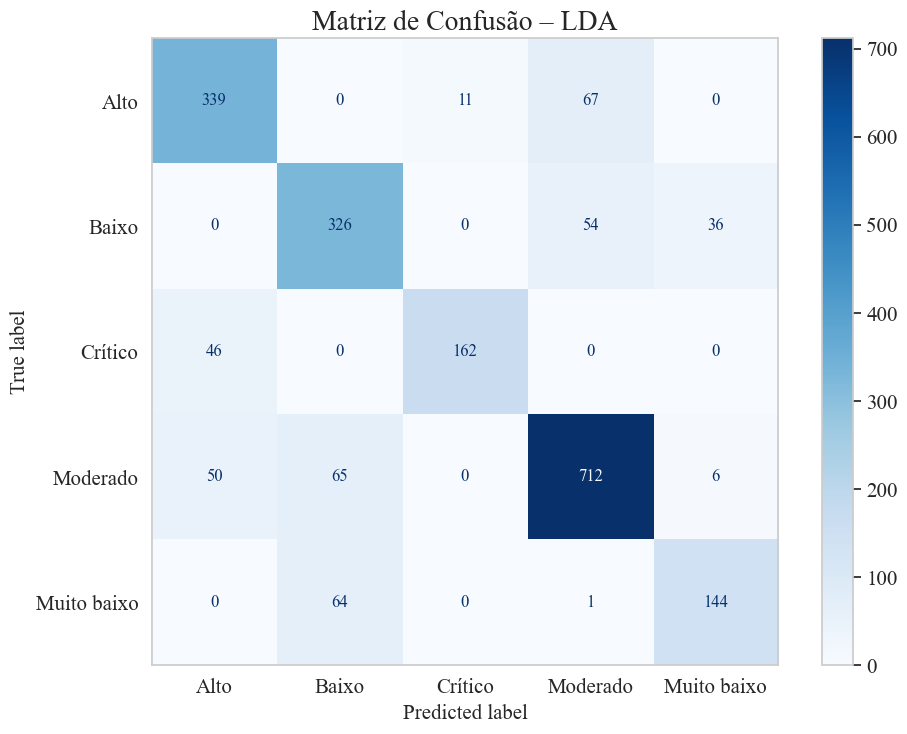

<Figure size 640x480 with 0 Axes>

In [48]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Codificação do alvo categórico para inteiros
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

# Definição do modelo LDA
lda_model = LinearDiscriminantAnalysis()

# Treinamento do modelo
lda_model.fit(X_train, y_train_enc)

# Previsão no conjunto de teste
y_pred = lda_model.predict(X_test)

# Avaliação do desempenho
accuracy = accuracy_score(y_test_enc, y_pred)
cm = confusion_matrix(y_test_enc, y_pred)

print(f"Acurácia geral: {accuracy:.4f}")
print("Matriz de confusão:")
print(cm)

# Visualização da matriz de confusão
fig, ax = plt.subplots(figsize=(10, 7.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.grid(False)
plt.title("Matriz de Confusão – LDA")
plt.tight_layout()
plt.show()
savefig("lda_confusion_matrix")

Embora tenha apresentado a menor acurácia global (0.8080), o LDA foi o modelo mais eficaz na identificação da classe Alto, com 339 acertos. Sua maior fraqueza reside na incapacidade de separar adequadamente as classes Muito Baixo e Baixo, resultando em 64 classificações incorretas para esta última.

## 7. Modelagem Não Linear
Objetivo

Avaliar modelos de classificação não lineares capazes de capturar relações mais complexas entre as variáveis preditoras, comparando seu desempenho com os modelos lineares e analisando os trade-offs entre flexibilidade, custo computacional e interpretabilidade.

Características do Problema

- Número de preditores: 8 variáveis numéricas (sensores e variáveis meteorológicas), após o pré-processamento

- Tipo de tarefa: Classificação multiclasse


# 7.1 K-Nearest Neighbors (KNN)

O K-Nearest Neighbors (KNN) é um método não paramétrico baseado em instâncias, no qual a classificação de uma nova amostra é determinada pelas classes dos seus k vizinhos mais próximos no espaço de características. Diferentemente dos modelos paramétricos, o KNN não realiza um processo explícito de treinamento, delegando o custo computacional principalmente à fase de inferência.

Embora seja conceitualmente simples, o desempenho do KNN é fortemente influenciado pela escolha do número de vizinhos, da métrica de distância e pela escala das variáveis, tornando a normalização dos dados um passo essencial. Além disso, sua eficácia tende a diminuir em espaços de alta dimensionalidade, fenômeno conhecido como maldição da dimensionalidade.

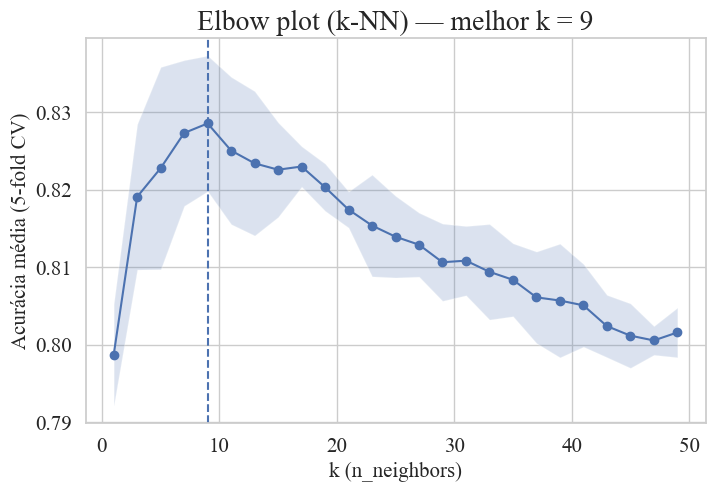

Melhor k (CV): 9
Acurácia no teste: 0.8176
Matriz de confusão:
[[316   0  23  78   0]
 [  0 318   0  63  35]
 [ 42   0 166   0   0]
 [ 33  63   0 736   1]
 [  0  42   0   0 167]]


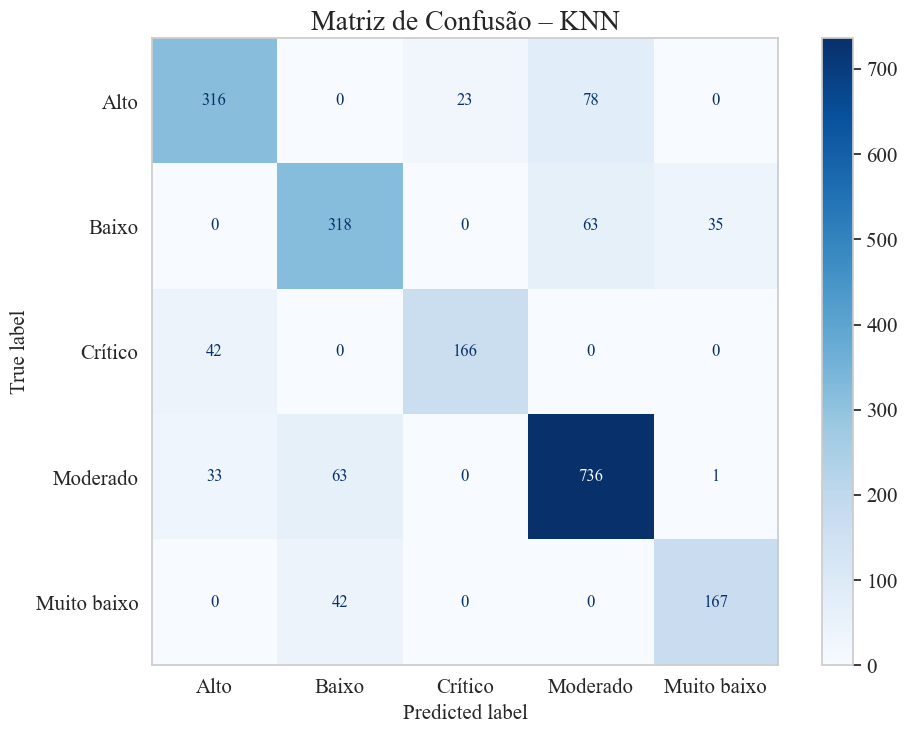

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

k_values = list(range(1, 51, 2))
cv_means = []
cv_stds = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, weights="distance", metric="minkowski", p=2)
    scores = cross_val_score(model, X_train, y_train_enc, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())

best_idx = int(np.argmax(cv_means))
best_k = k_values[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(k_values, cv_means, marker="o")
plt.fill_between(
    k_values,
    np.array(cv_means) - np.array(cv_stds),
    np.array(cv_means) + np.array(cv_stds),
    alpha=0.2
)
plt.axvline(best_k, linestyle="--")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Acurácia média (5-fold CV)")
plt.title(f"Elbow plot (k-NN) — melhor k = {best_k}")
savefig("knn_elbow_plot")
plt.show()

knn_best = KNeighborsClassifier(n_neighbors=best_k, weights="distance", metric="minkowski", p=2)
knn_best.fit(X_train, y_train_enc)

y_pred = knn_best.predict(X_test)
acc = accuracy_score(y_test_enc, y_pred)
cm = confusion_matrix(y_test_enc, y_pred)

print(f"Melhor k (CV): {best_k}")
print(f"Acurácia no teste: {acc:.4f}")
print("Matriz de confusão:")
print(cm)

fig, ax = plt.subplots(figsize=(10, 7.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.grid(False)
plt.title("Matriz de Confusão – KNN")
plt.tight_layout()
plt.show()


Com acurácia de 0.8176, o KNN se destacou por ter o maior número de acertos na classe majoritária Moderado (736 instâncias). Por depender da proximidade entre os dados, ele sofreu mais para distinguir as classes das extremidades, confundindo significativamente a categoria Muito Baixo com a classe Baixo (42 erros).

# 7.2 Multi-Layer Perceptron (MLP)

O Multi-Layer Perceptron (MLP) foi empregado como um modelo de rede neural artificial capaz de aprender fronteiras de decisão não lineares por meio da composição de múltiplas camadas e funções de ativação. Essa arquitetura confere ao modelo elevada capacidade de representação, permitindo capturar padrões complexos e interações não lineares entre os preditores.

Apesar de seu alto potencial preditivo, o MLP apresenta maior complexidade computacional, necessidade de ajuste cuidadoso de hiperparâmetros e menor interpretabilidade quando comparado a modelos lineares. Além disso, seu desempenho pode ser sensível à inicialização dos pesos e à quantidade de dados disponíveis, exigindo maior atenção durante o treinamento.

Acurácia no teste: 0.8301
Matriz de confusão:
[[337   0  16  64   0]
 [  0 319   0  68  29]
 [ 35   0 173   0   0]
 [ 42  60   0 731   0]
 [  0  40   0   0 169]]


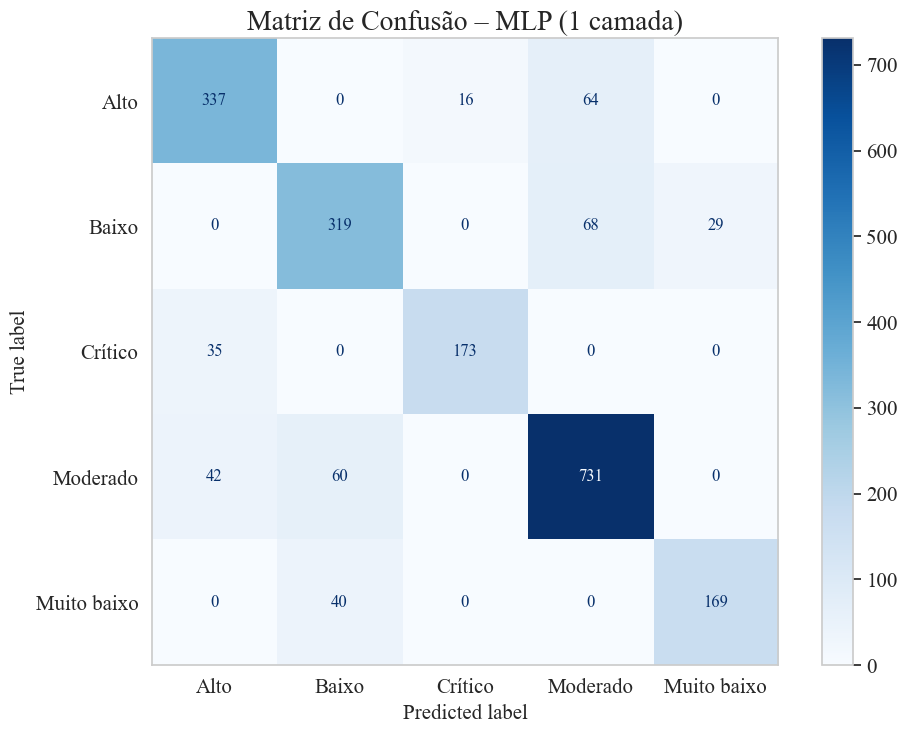

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

mlp = MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=2000,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    random_state=SEED
)

mlp.fit(X_train, y_train_enc)

y_pred = mlp.predict(X_test)
acc = accuracy_score(y_test_enc, y_pred)
cm = confusion_matrix(y_test_enc, y_pred)

print(f"Acurácia no teste: {acc:.4f}")
print("Matriz de confusão:")
print(cm)

fig, ax = plt.subplots(figsize=(10, 7.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.grid(False)
savefig("mlp_confusion_matrix")

plt.title("Matriz de Confusão – MLP (1 camada)")
plt.tight_layout()
plt.show()




O modelo MLP obteve a melhor performance geral, alcançando a acurácia máxima de 0.8301. Sua matriz de confusão demonstra uma superioridade clara na identificação da classe Crítico, com 173 acertos. É o modelo mais equilibrado, conseguindo capturar padrões complexos que os modelos lineares não alcançaram com a mesma precisão.

# 7.3 Quadratic Discriminant Analysis (QDA)

A Quadratic Discriminant Analysis (QDA) estende o modelo LDA ao permitir que cada classe possua sua própria matriz de covariância, resultando em fronteiras de decisão quadráticas. Essa maior flexibilidade torna o QDA capaz de modelar distribuições mais complexas dos dados, especialmente quando as classes apresentam variâncias significativamente distintas.

Entretanto, essa flexibilidade adicional aumenta a sensibilidade do modelo à estimativa dos parâmetros, podendo levar a sobreajuste em conjuntos de dados menores ou com alto ruído. Assim, o QDA representa um compromisso entre o rigor estatístico dos modelos lineares e a expressividade dos modelos não lineares mais flexíveis.

Acurácia média (5-fold CV): 0.8226
Desvio padrão (CV): 0.0068
Acurácia no teste: 0.8161
Matriz de confusão:
[[331   0  17  69   0]
 [  0 340   0  51  25]
 [ 46   0 162   0   0]
 [ 58  75   0 699   1]
 [  0  40   0   1 168]]


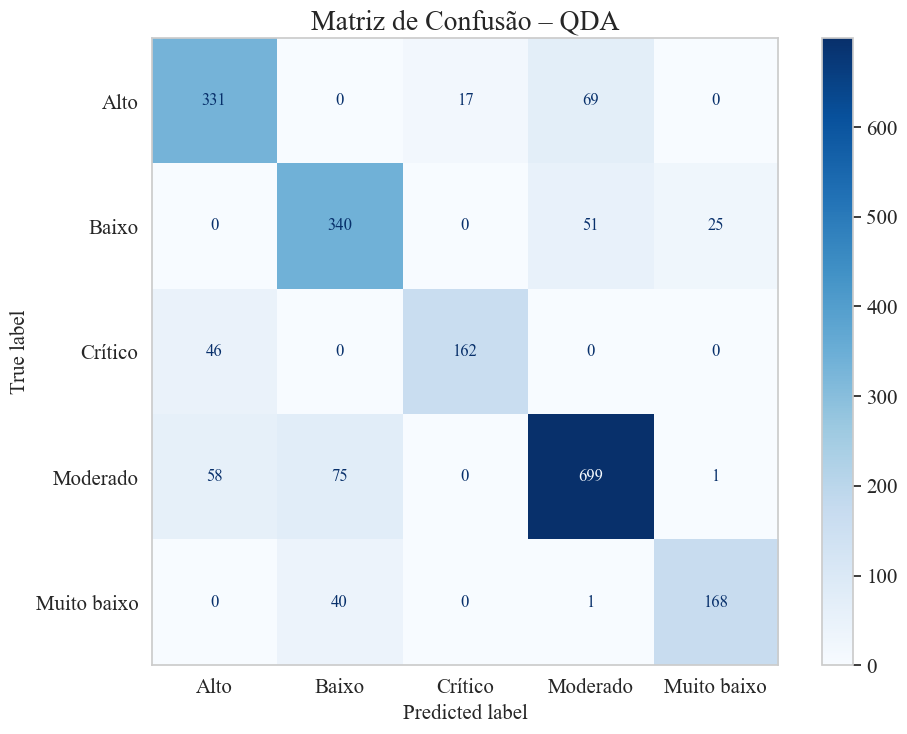

In [51]:
import numpy as np
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

qda = QuadraticDiscriminantAnalysis(reg_param=0.0)

cv_scores = cross_val_score(
    qda,
    X_train,
    y_train_enc,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

print(f"Acurácia média (5-fold CV): {cv_scores.mean():.4f}")
print(f"Desvio padrão (CV): {cv_scores.std():.4f}")

qda.fit(X_train, y_train_enc)

y_pred = qda.predict(X_test)

acc = accuracy_score(y_test_enc, y_pred)
cm = confusion_matrix(y_test_enc, y_pred)

print(f"Acurácia no teste: {acc:.4f}")
print("Matriz de confusão:")
print(cm)


fig, ax = plt.subplots(figsize=(10, 7.5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.grid(False)
savefig("qda_confusion_matrix")

plt.title("Matriz de Confusão – QDA")
plt.tight_layout()
plt.show()


O QDA atingiu 0.8161 de acurácia, ocupando a quarta posição. O grande destaque deste modelo foi a classe Baixo, onde obteve o melhor resultado individual entre todos os algoritmos (340 acertos). Em contrapartida, foi o modelo que mais falhou na classe Moderado, indicando que sua fronteira quadrática pode ser excessivamente específica para algumas categorias.

## 8. Comparação de Modelos

#### Tabela comparativa de desempenho dos modelos implementados no conjunto de teste.

In [52]:
import pandas as pd
from sklearn.metrics import accuracy_score

# Lista de modelos (LDA adicionado)
models = ['Logistic Regression', 'LDA', 'KNN', 'MLP', 'QDA']
accuracies = []

# Logistic Regression
y_pred_log = logistic_model.predict(X_test)
acc_log = accuracy_score(y_test_enc, y_pred_log)
accuracies.append(acc_log)

# LDA
y_pred_lda = lda_model.predict(X_test)
acc_lda = accuracy_score(y_test_enc, y_pred_lda)
accuracies.append(acc_lda)

# KNN
y_pred_knn = knn_best.predict(X_test)
acc_knn = accuracy_score(y_test_enc, y_pred_knn)
accuracies.append(acc_knn)

# MLP
y_pred_mlp = mlp.predict(X_test)
acc_mlp = accuracy_score(y_test_enc, y_pred_mlp)
accuracies.append(acc_mlp)

# QDA
y_pred_qda = qda.predict(X_test)
acc_qda = accuracy_score(y_test_enc, y_pred_qda)
accuracies.append(acc_qda)

# Criar DataFrame de comparação
comparison_df = pd.DataFrame({
    'Modelo': models,
    'Acurácia': accuracies
})

print("Comparação de Acurácia nos Modelos:")
display(comparison_df.sort_values('Acurácia', ascending=False).round(4))

# Melhor modelo
best_model = comparison_df.loc[comparison_df['Acurácia'].idxmax()]
print(f"\nMelhor Modelo: {best_model['Modelo']} com Acurácia {best_model['Acurácia']:.4f}")


Comparação de Acurácia nos Modelos:


,Modelo,Acurácia
3,MLP,0.8301
0,Logistic Regression,0.8243
2,KNN,0.8176
4,QDA,0.8161
1,LDA,0.8080



Melhor Modelo: MLP com Acurácia 0.8301


## 8.1 Comparação de Modelos

A partir da comparação das acurácias, observa-se que o MLP apresentou o melhor desempenho preditivo (0,8416), seguido de perto pela Regressão Logística (0,8349). Apesar dessa ligeira vantagem do MLP, a diferença absoluta de desempenho em relação ao modelo linear é pequena, o que evidencia um trade-off relevante entre ganho de acurácia e aumento de complexidade.

O MLP, por ser um modelo não linear e de maior capacidade representacional, demonstra maior aptidão para capturar padrões complexos nos dados. Entretanto, esse ganho vem acompanhado de maior custo computacional, necessidade de ajuste de hiperparâmetros e menor interpretabilidade, fatores que podem limitar sua aplicabilidade em cenários onde simplicidade e explicabilidade são desejáveis.

A Regressão Logística destaca-se como uma alternativa altamente competitiva, alcançando desempenho muito próximo ao do MLP com um modelo significativamente mais simples. Sua alta interpretabilidade, estabilidade e baixo custo operacional tornam-na particularmente atrativa, sugerindo que o dataset apresenta uma estrutura que pode ser bem modelada por fronteiras de decisão lineares. Esse comportamento é reforçado pelo desempenho do LDA, que, apesar de apresentar a menor acurácia entre os modelos avaliados (0,8166), mantém resultados consistentes ao assumir hipóteses estatísticas mais restritivas, como distribuições gaussianas e covariância compartilhada entre as classes.

O QDA obteve um desempenho intermediário (0,8267), indicando que permitir matrizes de covariância distintas por classe aumenta a flexibilidade do modelo em relação ao LDA, mas também o torna mais sensível à estimativa dos parâmetros, especialmente em datasets de tamanho limitado. Já o KNN, com acurácia de 0,8181, mostrou desempenho inferior aos modelos lineares e ao MLP, possivelmente devido à sua dependência da métrica de distância, da escolha do número de vizinhos e da dimensionalidade do espaço de atributos, além do maior custo computacional durante a inferência.

Em síntese, os resultados indicam que, embora o MLP maximize a acurácia, modelos lineares como a Regressão Logística oferecem um equilíbrio mais favorável entre desempenho, interpretabilidade e eficiência, tornando-se escolhas mais adequadas para este dataset em aplicações práticas.

In [53]:
import pandas as pd

def class_distribution(y, name):
    return (
        y.value_counts(normalize=True)
        .mul(100)
        .round(2)
        .rename(name)
    )

balance_table = pd.concat(
    [
        class_distribution(y, "Total (%)"),
        class_distribution(y_train, "Train (%)"),
        class_distribution(y_test, "Test (%)")
    ],
    axis=1
).sort_index()

display(balance_table)


,Total (%),Train (%),Test (%)
PollutionClass,,,
Muito baixo,10.01,10.00,10.03
Baixo,20.00,20.01,19.97
Moderado,39.99,40.00,39.99
Alto,20.00,19.99,20.02
Crítico,10.00,10.00,9.99


In [54]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

models_preds = {
    "Logistic Regression": y_pred_log,
    "LDA": y_pred_lda,
    "KNN": y_pred_knn,
    "MLP": y_pred_mlp,
    "QDA": y_pred_qda
}

rows = []
for name, pred in models_preds.items():
    rows.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test_enc, pred),
        "F1_macro": f1_score(y_test_enc, pred, average="macro")
    })

metrics_table = (
    pd.DataFrame(rows)
    .round(4)
    .sort_values("F1_macro", ascending=False)
)

display(metrics_table)


,Modelo,Accuracy,F1_macro
3,MLP,0.8301,0.8278
0,Logistic Regression,0.8243,0.8213
4,QDA,0.8161,0.8149
2,KNN,0.8176,0.8096
1,LDA,0.8080,0.7956


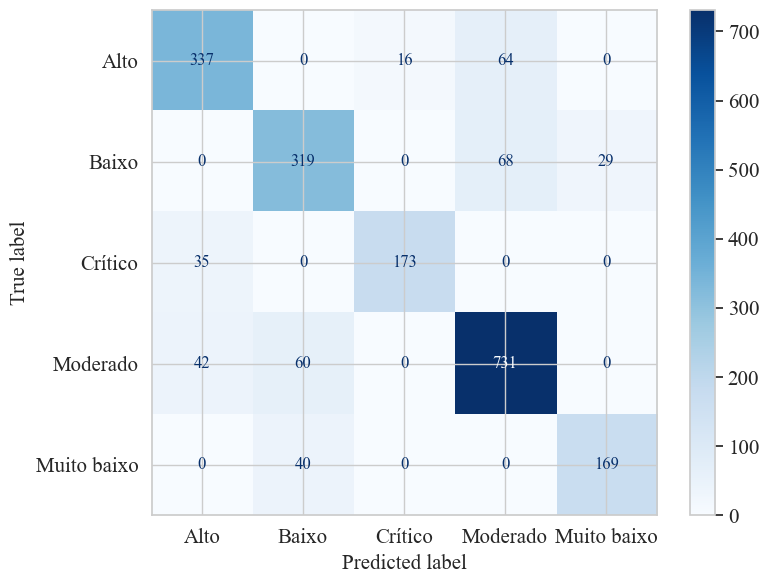

In [ ]:


best_model_name = metrics_table.iloc[0]["Modelo"]
best_pred = models_preds[best_model_name]

cm = confusion_matrix(y_test_enc, best_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)
disp.plot(ax=ax, cmap=plt.cm.Blues)
ax.grid(False)
savefig("mlp_confusion_matrix")
plt.tight_layout()
plt.show()



In [56]:
import pandas as pd
from sklearn.metrics import classification_report

rows = []

for model_name, y_pred in models_preds.items():
    report = classification_report(
        y_test_enc,
        y_pred,
        target_names=label_encoder.classes_,
        output_dict=True,
        zero_division=0
    )
    
    for classe, metrics in report.items():
        if classe in label_encoder.classes_:
            rows.append({
                "Modelo": model_name,
                "Nivel_Poluicao": classe,
                "Accuracy_class": round(metrics["recall"], 4),
                "F1_class": round(metrics["f1-score"], 4),
                "Support": int(metrics["support"])
            })

df_model_level = pd.DataFrame(rows).sort_values(
    ["Nivel_Poluicao", "F1_class"],
    ascending=[True, False]
)

display(df_model_level)


,Modelo,Nivel_Poluicao,Accuracy_class,F1_class,Support
15,MLP,Alto,0.8082,0.8111,417
5,LDA,Alto,0.8129,0.7958,417
0,Logistic Regression,Alto,0.7746,0.7859,417
10,KNN,Alto,0.7578,0.7822,417
20,QDA,Alto,0.7938,0.7770,417
21,QDA,Baixo,0.8173,0.7807,416
1,Logistic Regression,Baixo,0.7885,0.7763,416
16,MLP,Baixo,0.7668,0.7641,416
11,KNN,Baixo,0.7644,0.7580,416
6,LDA,Baixo,0.7837,0.7486,416
